# KernelSynth coverage with pooled ARIMA-CSS

## Abstract

This experiment evaluates whether bounded ARIMA models reproduce the stochastic behavior of every one of the 33 official KernelSynth bank entries and the same 20 seeded composite kernels used in the AR baseline. The comparison keeps the mechanisms, trajectories, seeds, metrics, thresholds, and best-configuration rule fixed. ARIMA adds moving-average terms and regular differencing, allowing the experiment to isolate what these two capabilities recover beyond finite-order AR. Estimation uses pooled conditional sum of squares (CSS): all training trajectories from one mechanism share coefficients while their boundaries remain independent.

In [1]:
from __future__ import annotations

import json
import platform
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src"))

from tsfmxai.baselines import fit_pooled_arma, one_step_nmse, simulate_pooled_arma
from tsfmxai.evaluation import (
    DEFAULT_THRESHOLDS,
    channel_metrics,
    distribution_metrics,
    dominant_periods,
    passes_channel_coverage,
    passes_coverage,
    violation_score,
)
from tsfmxai.generators import (
    draw_retained_kernel_case,
    draw_retained_lmc_case,
    retained_kernel_cases,
    retained_lmc_mechanisms,
)

GLOBAL_SEED = 20260930
LENGTH = 1024
N_TRAIN = 16
N_TEST = 16
RIDGE = 1e-5
CSS_ITERATIONS = 4
MAX_ACF_LAG = 64
THRESHOLDS = dict(DEFAULT_THRESHOLDS)
CROSS_CORR_THRESHOLD = 0.10


CONFIGURATIONS = [
    (1, 0, 0), (2, 0, 0), (4, 0, 0), (8, 0, 0), (16, 0, 0),
    (32, 0, 0), (64, 0, 0), (128, 0, 0), (256, 0, 0),
    (1, 0, 1), (2, 0, 1), (4, 0, 1), (8, 0, 1), (16, 0, 1),
    (2, 1, 1), (4, 1, 1), (8, 1, 1),
]

def configuration_name(order):
    return f"ARIMA{tuple(order)}"

print(f"Repository root: {REPO_ROOT}")
print(f"ARIMA configurations: {[configuration_name(item) for item in CONFIGURATIONS]}")

Repository root: C:\Users\mateu\repos\tsfmxai
ARIMA configurations: ['ARIMA(1, 0, 0)', 'ARIMA(2, 0, 0)', 'ARIMA(4, 0, 0)', 'ARIMA(8, 0, 0)', 'ARIMA(16, 0, 0)', 'ARIMA(32, 0, 0)', 'ARIMA(64, 0, 0)', 'ARIMA(128, 0, 0)', 'ARIMA(256, 0, 0)', 'ARIMA(1, 0, 1)', 'ARIMA(2, 0, 1)', 'ARIMA(4, 0, 1)', 'ARIMA(8, 0, 1)', 'ARIMA(16, 0, 1)', 'ARIMA(2, 1, 1)', 'ARIMA(4, 1, 1)', 'ARIMA(8, 1, 1)']


The configuration cell fixes the exact ARIMA search before inspecting results. The `q=0` configurations embed the complete AR search as a nested control. Differencing order `d=1` and the `q=1` configurations then test information absent from the AR baseline.

In [2]:
CASES = retained_kernel_cases(global_seed=GLOBAL_SEED, length=LENGTH, composition_count=20)
assert len(CASES) == 53
display(pd.DataFrame([{key: case[key] for key in ["id", "category", "family", "periods"]} for case in CASES]))

,id,category,family,periods
0,periodic_01_p24,base,periodic,[24]
1,periodic_02_p48,base,periodic,[48]
2,periodic_03_p96,base,periodic,[96]
3,periodic_04_p168,base,periodic,[168]
4,periodic_05_p336,base,periodic,[336]
5,periodic_06_p672,base,periodic,[672]
6,periodic_07_p7,base,periodic,[7]
7,periodic_08_p14,base,periodic,[14]
8,periodic_09_p30,base,periodic,[30]
9,periodic_10_p60,base,periodic,[60]


The retained set is identical to the AR experiment: 33 ordered bank entries plus 20 deterministic compositions. Period metadata is retained for the later SARIMA branch but is not given to ARIMA.

In [3]:
rows = []
reference_series = {}
for case_index, case in enumerate(CASES):
    train, test = draw_retained_kernel_case(
        case, case_index=case_index, global_seed=GLOBAL_SEED,
        n_train=N_TRAIN, n_test=N_TEST,
    )
    reference_series[case["id"]] = test[0].copy()
    for configuration_index, order in enumerate(CONFIGURATIONS):
        name = configuration_name(order)
        try:
            fit = fit_pooled_arma(train, order=order, ridge=RIDGE, css_iterations=CSS_ITERATIONS)
            simulation_seed = (
                GLOBAL_SEED + 1_000_000 + 1000 * case_index + order[0]
                if order[1] == 0 and order[2] == 0
                else GLOBAL_SEED + 4_000_000 + 1000 * case_index + configuration_index
            )
            generated = simulate_pooled_arma(
                fit, test[:, :fit.start], length=LENGTH,
                rng=np.random.default_rng(simulation_seed),
            )
            metrics = distribution_metrics(test, generated, fit.start, max_acf_lag=MAX_ACF_LAG)
            forecast_nmse = one_step_nmse(fit, test)
            error = None
        except Exception as exc:
            metrics = {key: float("inf") for key in THRESHOLDS}
            forecast_nmse = float("inf")
            error = f"{type(exc).__name__}: {exc}"
        rows.append({
            "function": case["id"], "category": case["category"], "family": case["family"],
            "formula": case["formula"], "periods": ",".join(map(str, case["periods"])),
            "configuration": name, "order": int(max(order[0], order[2])),
            "p": order[0], "d": order[1], "q": order[2], "forecast_nmse": forecast_nmse,
            **metrics, "well_covered": passes_coverage(metrics, THRESHOLDS), "error": error,
        })

results = pd.DataFrame(rows)
results["violation_score"] = results.apply(lambda row: violation_score(row, thresholds=THRESHOLDS), axis=1)
best = (results.sort_values(["function", "violation_score", "forecast_nmse", "configuration"])
        .groupby("function", as_index=False).first())
status = results.groupby("function")["well_covered"].any().rename("well_covered_any_order").reset_index()
best = best.merge(status, on="function")
coverage_curve = results.groupby("configuration")["well_covered"].mean().sort_values()
display(best[["function", "family", "configuration", "well_covered_any_order", "acf_mae",
              "psd_jsd", "abs_log_variance_ratio", "standardized_wasserstein", "forecast_nmse"]].round(4))

C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:196: RuntimeWarning: overflow encountered in square
  return float(np.mean((target - predicted) ** 2) / (np.var(target) + 1e-12))
C:\Users\mateu\repos\tsfmxai\.venv\Lib\site-packages\numpy\core\_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:153: RuntimeWarning: overflow encountered in matmul
  prediction += residuals[:, time_index - lag] @ coefficient


,function,family,configuration,well_covered_any_order,acf_mae,psd_jsd,abs_log_variance_ratio,standardized_wasserstein,forecast_nmse
0,composite_01,composite,"ARIMA(32, 0, 0)",True,0.0549,0.0057,0.1096,0.0571,0.0000
1,composite_02,composite,"ARIMA(256, 0, 0)",True,0.0051,0.0001,0.0147,0.0073,0.0000
2,composite_03,composite,"ARIMA(128, 0, 0)",True,0.0846,0.0319,0.2392,0.0906,0.0000
3,composite_04,composite,"ARIMA(256, 0, 0)",True,0.0129,0.0006,0.0077,0.0241,0.0000
4,composite_05,composite,"ARIMA(256, 0, 0)",True,0.0001,0.0000,0.0000,0.0001,0.0000
5,composite_06,composite,"ARIMA(128, 0, 0)",False,0.0302,0.0339,0.2565,0.1980,0.0000
6,composite_07,composite,"ARIMA(256, 0, 0)",True,0.0137,0.0031,0.0261,0.0582,0.0001
7,composite_08,composite,"ARIMA(256, 0, 0)",True,0.0846,0.0521,0.1737,0.1633,0.0032
8,composite_09,composite,"ARIMA(128, 0, 0)",True,0.0136,0.0485,0.2365,0.0933,0.0000
9,composite_10,composite,"ARIMA(256, 0, 0)",True,0.0172,0.0000,0.0032,0.0194,0.0000


For each mechanism, ARIMA is fitted once per configuration to all 16 training trajectories. Sixteen independent test trajectories initialize stochastic simulations. Coverage still requires all four distributional metrics to pass; one-step NMSE is reported separately.

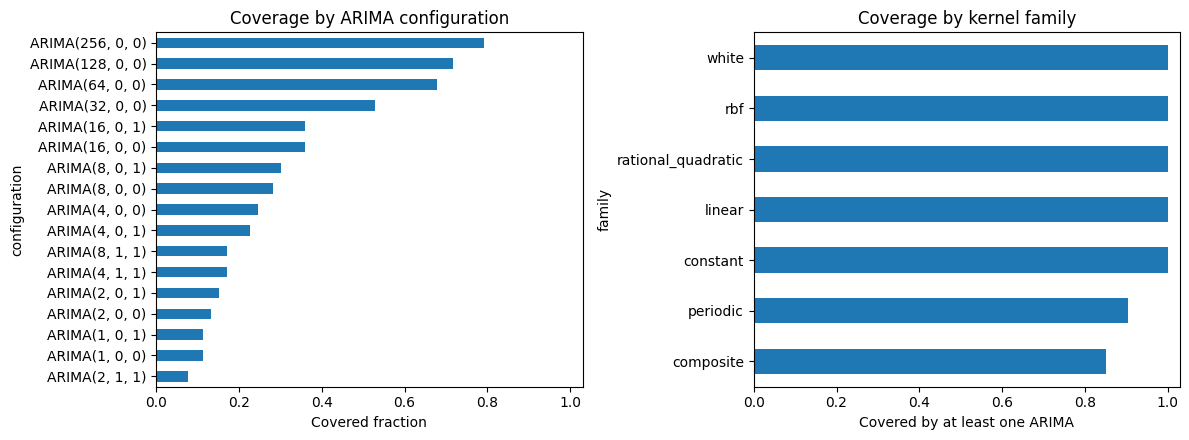

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
coverage_curve.plot.barh(ax=axes[0])
axes[0].set_xlim(0, 1.03); axes[0].set_xlabel("Covered fraction")
axes[0].set_title("Coverage by ARIMA configuration")
best.groupby("family")["well_covered_any_order"].mean().sort_values().plot.barh(ax=axes[1])
axes[1].set_xlim(0, 1.03); axes[1].set_xlabel("Covered by at least one ARIMA")
axes[1].set_title("Coverage by kernel family")
fig.tight_layout(); plt.show()

The left panel compares configurations under the same threshold, while the right panel asks whether any ARIMA configuration covers each mechanism family.

In [5]:
covered_functions = best.loc[best.well_covered_any_order, "function"].tolist()
not_covered_functions = best.loc[~best.well_covered_any_order, "function"].tolist()
diagnostic_series = [
    {"benchmark": "kernelsynth", "mechanism": function, "evaluation_mode": "univariate",
     "values": reference_series[function].tolist()}
    for function in not_covered_functions
]
print(f"WELL COVERED ({len(covered_functions)}/{len(best)}):")
print("\n".join(f"  - {name}" for name in covered_functions) or "  (none)")
print(f"\nNOT WELL COVERED ({len(not_covered_functions)}/{len(best)}):")
print("\n".join(f"  - {name}" for name in not_covered_functions) or "  (none)")
display(best[["function", "formula", "configuration", "well_covered_any_order"]])

WELL COVERED (48/53):
  - composite_01
  - composite_02
  - composite_03
  - composite_04
  - composite_05
  - composite_07
  - composite_08
  - composite_09
  - composite_10
  - composite_11
  - composite_12
  - composite_15
  - composite_16
  - composite_17
  - composite_18
  - composite_19
  - composite_20
  - constant_1
  - linear_sigma0
  - linear_sigma1
  - linear_sigma10
  - periodic_01_p24
  - periodic_02_p48
  - periodic_03_p96
  - periodic_04_p168
  - periodic_05_p336
  - periodic_07_p7
  - periodic_08_p14
  - periodic_09_p30
  - periodic_10_p60
  - periodic_11_p365
  - periodic_13_p4
  - periodic_14_p26
  - periodic_15_p52
  - periodic_16_p4
  - periodic_17_p6
  - periodic_18_p12
  - periodic_19_p4
  - periodic_20_p40
  - periodic_21_p10
  - rbf_scale0.1
  - rbf_scale1
  - rbf_scale10
  - rq_alpha0.1
  - rq_alpha1
  - rq_alpha10
  - white_level0.1
  - white_level1

NOT WELL COVERED (5/53):
  - composite_06
  - composite_13
  - composite_14
  - periodic_06_p672
  - periodic_1

,function,formula,configuration,well_covered_any_order
0,composite_01,"((ExpSineSquared(length_scale=1, periodicity=4...","ARIMA(32, 0, 0)",True
1,composite_02,"(((ExpSineSquared(length_scale=1, periodicity=...","ARIMA(256, 0, 0)",True
2,composite_03,"((((ExpSineSquared(length_scale=1, periodicity...","ARIMA(128, 0, 0)",True
3,composite_04,"(((((ExpSineSquared(length_scale=1, periodicit...","ARIMA(256, 0, 0)",True
4,composite_05,"((ExpSineSquared(length_scale=1, periodicity=1...","ARIMA(256, 0, 0)",True
5,composite_06,(((ConstantKernel(constant_value=1)) + (ExpSin...,"ARIMA(128, 0, 0)",False
6,composite_07,"((((ExpSineSquared(length_scale=1, periodicity...","ARIMA(256, 0, 0)",True
7,composite_08,"(((((ExpSineSquared(length_scale=1, periodicit...","ARIMA(256, 0, 0)",True
8,composite_09,"((ExpSineSquared(length_scale=1, periodicity=2...","ARIMA(128, 0, 0)",True
9,composite_10,"(((RationalQuadratic(length_scale=1, alpha=10)...","ARIMA(256, 0, 0)",True


Failed mechanisms retain one deterministic reference trajectory inside the experiment record. The comparison notebook uses these values only after the same case also fails AR and SARIMA.

In [6]:
def git_output(*args):
    try:
        return subprocess.check_output(["git", *args], cwd=REPO_ROOT, text=True).strip()
    except Exception as exc:
        return f"unavailable: {exc}"

function_manifest = [
    {key: case[key] for key in ["id", "category", "family", "formula", "periods"]}
    for case in CASES
]

experiment_record = {
    "experiment_id": "kernelsynth_arima_css_coverage_001", "status": "completed",
    "research_question": "Which retained KernelSynth mechanisms are well approximated by bounded pooled ARIMA-CSS models?",
    "hypothesis": "Moving-average terms and differencing cover some mechanisms missed by AR, while dense smooth GP covariance may remain difficult.",
    "configuration": {"length": LENGTH, "n_train": N_TRAIN, "n_test": N_TEST,
                      "orders": [list(item) for item in CONFIGURATIONS], "ridge": RIDGE,
                      "css_iterations": CSS_ITERATIONS, "max_acf_lag": MAX_ACF_LAG,
                      "thresholds": THRESHOLDS, "functions": function_manifest,
                      "estimator": "pooled conditional sum of squares"},
    "provenance": {"kernel_repository": "https://github.com/amazon-science/chronos-forecasting",
                   "kernel_commit": "10afa9ebe016e514f9d7dc1aa873f66af57e116b",
                   "kernel_source": "scripts/kernel-synth.py", "project_head": git_output("rev-parse", "HEAD")},
    "seed_usage": {"global_seed": GLOBAL_SEED,
                   "policy": "same retained train/test draws as AR; simulation seed derived per function and configuration"},
    "environment": {"python": sys.version, "platform": platform.platform(), "numpy": np.__version__,
                    "scipy": scipy.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                    "hardware": "CPU"},
    "metrics": {"coverage_fraction_by_configuration": {str(k): float(v) for k, v in coverage_curve.items()},
                "best_row_per_function": best.to_dict(orient="records")},
    "covered_functions": covered_functions, "not_well_covered_functions": not_covered_functions,
    "diagnostic_series": diagnostic_series,
    "scientific_summary": f"{len(covered_functions)}/{len(best)} retained KernelSynth mechanisms were covered by at least one ARIMA-CSS configuration.",
    "limitations": ["Operational thresholds need sensitivity analysis.", "No Monte Carlo confidence intervals.",
                    "CSS is a tractable pooled estimator rather than exact maximum-likelihood ARIMA.",
                    "The finite retained compositions do not exhaust the KernelSynth prior."],
    "reproduction": {"command": r".\.venv\Scripts\jupyter.exe nbconvert --to notebook --execute experiments\autoregressive_process_coverage\ARIMA\01_kernelsynth_arima_coverage.ipynb --output 01_kernelsynth_arima_coverage.ipynb --ExecutePreprocessor.timeout=3600"},
}
print("COMPLETE EXPERIMENT RECORD")
print(json.dumps(experiment_record, indent=2, ensure_ascii=False, default=lambda value: float(value)))

COMPLETE EXPERIMENT RECORD
{
  "experiment_id": "kernelsynth_arima_css_coverage_001",
  "status": "completed",
  "research_question": "Which retained KernelSynth mechanisms are well approximated by bounded pooled ARIMA-CSS models?",
  "hypothesis": "Moving-average terms and differencing cover some mechanisms missed by AR, while dense smooth GP covariance may remain difficult.",
  "configuration": {
    "length": 1024,
    "n_train": 16,
    "n_test": 16,
    "orders": [
      [
        1,
        0,
        0
      ],
      [
        2,
        0,
        0
      ],
      [
        4,
        0,
        0
      ],
      [
        8,
        0,
        0
      ],
      [
        16,
        0,
        0
      ],
      [
        32,
        0,
        0
      ],
      [
        64,
        0,
        0
      ],
      [
        128,
        0,
        0
      ],
      [
        256,
        0,
        0
      ],
      [
        1,
        0,
        1
      ],
      [
        2,
        0

The final cell is the complete experiment record: configuration, provenance, seeds, environment, metrics, diagnostic trajectories, limitations, and reproduction command are stored together in the executed notebook.